<a href="https://colab.research.google.com/github/khamanojh/kaggle-exercise/blob/main/03_pizza_conjoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. Pizza コンジョイン

In [1]:
import os
from google.colab import userdata

# Kaggle 認証（キーはコードに直書きしない）
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# データは Colab 内の一時領域に置く（Drive の許可は不要）
DATA_DIR = '/content/data/pizza'
OUT_DIR = '/content/outputs/pizza'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

In [6]:
!pip install -q -U kaggle
!kaggle datasets download -d sachinsin8h/pizza-attributes-dataset-for-conjoint-analysis -p {DATA_DIR} --unzip
!ls -la {DATA_DIR}

Dataset URL: https://www.kaggle.com/datasets/sachinsin8h/pizza-attributes-dataset-for-conjoint-analysis
License(s): unknown
100% 471/471 [00:00<00:00, 1.13MB/s]

total 12
drwxr-xr-x 2 root root 4096 Oct  4 13:16 .
drwxr-xr-x 3 root root 4096 Oct  4 13:12 ..
-rw-r--r-- 1 root root 1020 Oct  4 13:16 pizza_data.csv


In [8]:
import pandas as pd

df = pd.read_csv(f'{DATA_DIR}/pizza_data.csv')

print(df.shape)
df.head(20)

(16, 9)


,brand,price,weight,crust,cheese,size,toppings,spicy,ranking
0,Dominos,$1.00,100g,thin,Mozzarella,regular,paneer,normal,11
1,Pizza hut,$3.00,100g,thin,Cheddar,large,mushroom,normal,12
2,Onesta,$4.00,200g,thin,Mozzarella,regular,mushroom,normal,9
3,Pizza hut,$4.00,400g,thick,Cheddar,regular,paneer,normal,2
4,Pizza hut,$2.00,300g,thin,Mozzarella,regular,mushroom,extra,8
5,Pizza hut,$1.00,200g,thick,Mozzarella,large,paneer,extra,13
6,Onesta,$3.00,300g,thick,Mozzarella,large,paneer,normal,7
7,Dominos,$4.00,300g,thin,Cheddar,large,paneer,extra,4
8,Dominos,$2.00,400g,thick,Mozzarella,large,mushroom,normal,5
9,Oven Story,$4.00,100g,thick,Mozzarella,large,mushroom,extra,16


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# データのコピーを作成
df_analysis = df.copy()

# 順位（1が最高、16が最低）を「効用（Utility）」に変換（値が大きいほど好ましい状態にする）
# 16点満点で、1位が16点、16位が1点となるように変換
df_analysis['utility_score'] = 17 - df_analysis['ranking']

# カテゴリカル属性の定義
attributes = ['brand', 'price', 'weight', 'crust', 'cheese', 'size', 'toppings', 'spicy']

# ダミー変数を生成（多重共線性を避けるため drop_first=True としたいが、全ての水準の効用を見るために一旦全てダミー化して回帰にかけます）
X = pd.get_dummies(df_analysis[attributes], columns=attributes, dtype=int)
y = df_analysis['utility_score']

# 定数項を追加して線形回帰を実行
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# 各水準の係数（部分効用）を抽出
coef_df = pd.DataFrame({
    'feature': model.params.index,
    'coef': model.params.values
})
# 定数項（const）は除く
coef_df = coef_df[coef_df['feature'] != 'const']

# 属性名と水準名に分割
coef_df['attribute'] = coef_df['feature'].apply(lambda x: x.split('_')[0])
coef_df['level'] = coef_df['feature'].apply(lambda x: '_'.join(x.split('_')[1:]))

# 各属性内での最大値と最小値のレンジ（幅）を計算して重要度を算出
attribute_ranges = {}
for attr in attributes:
    attr_coefs = coef_df[coef_df['attribute'] == attr]['coef']
    attribute_ranges[attr] = attr_coefs.max() - attr_coefs.min()

total_range = sum(attribute_ranges.values())
importance = {k: (v / total_range) * 100 for k, v in attribute_ranges.items()}
importance_df = pd.DataFrame(list(importance.items()), columns=['Attribute', 'Importance (%)']).sort_values(by='Importance (%)', ascending=False)

display(importance_df)

/tmp/ipykernel_2133/2987820581.py:22: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y, X).fit()


,Attribute,Importance (%)
2,weight,51.190476
3,crust,16.666667
6,toppings,10.714286
1,price,7.142857
7,spicy,7.142857
5,size,2.380952
0,brand,2.380952
4,cheese,2.380952


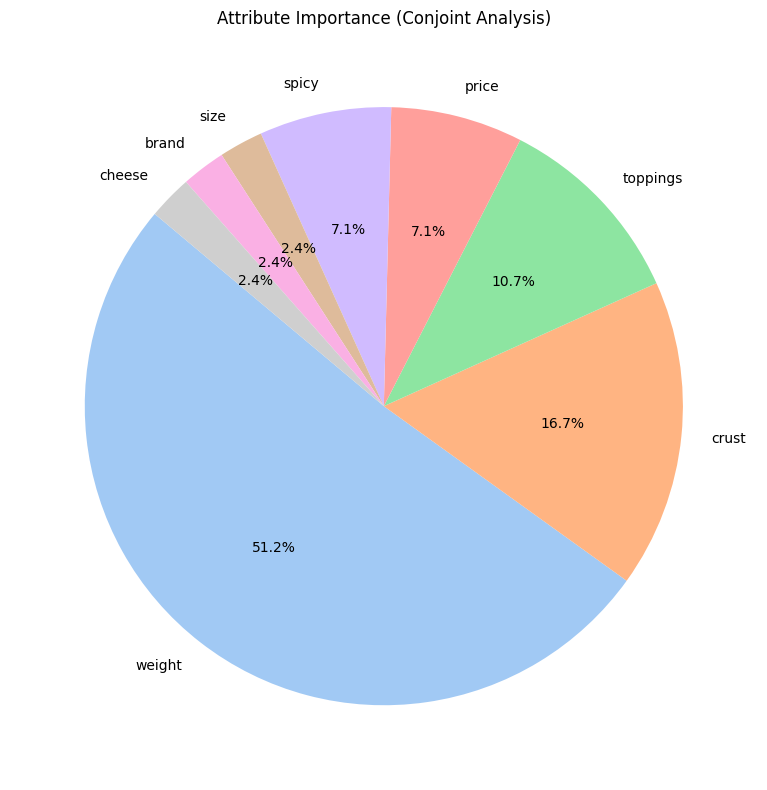

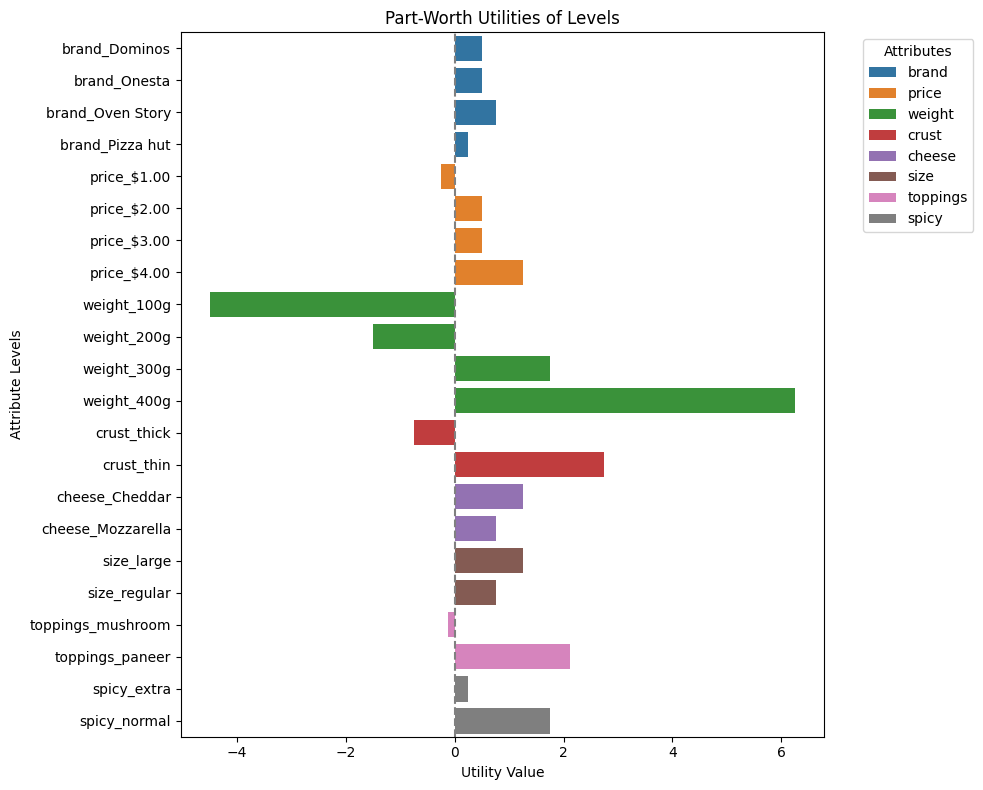

In [10]:
# 可視化: 属性の重要度（円グラフ）
plt.figure(figsize=(8, 8))
plt.pie(importance_df['Importance (%)'], labels=importance_df['Attribute'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Attribute Importance (Conjoint Analysis)')
plt.tight_layout()
plt.show()

# 可視化: 部分効用値（棒グラフ）
plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df, x='coef', y='feature', hue='attribute', dodge=False)
plt.axvline(0, color='gray', linestyle='--')
plt.title('Part-Worth Utilities of Levels')
plt.xlabel('Utility Value')
plt.ylabel('Attribute Levels')
plt.legend(title='Attributes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

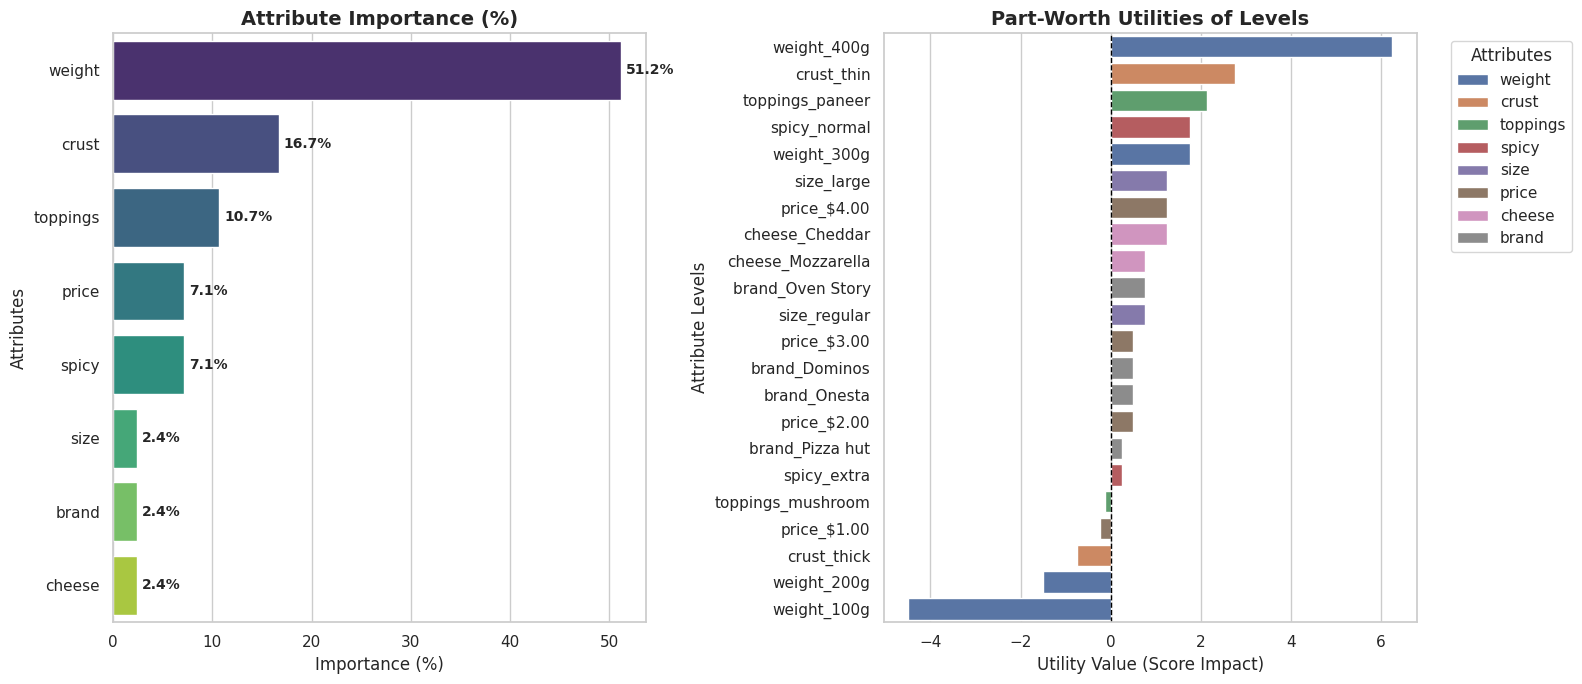

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# グラフのスタイル設定
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. 属性の重要度の棒グラフ
sns.barplot(
    x='Importance (%)',
    y='Attribute',
    data=importance_df,
    ax=axes[0],
    palette='viridis',
    hue='Attribute',
    legend=False
)
axes[0].set_title('Attribute Importance (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance (%)', fontsize=12)
axes[0].set_ylabel('Attributes', fontsize=12)
for index, value in enumerate(importance_df['Importance (%)']):
    axes[0].text(value + 0.5, index, f'{value:.1f}%', va='center', fontsize=10, fontweight='bold')

# 2. 部分効用値（Part-Worth Utilities）の棒グラフ
# 属性ごとに色分けして表示
sns.barplot(
    x='coef',
    y='feature',
    data=coef_df.sort_values(by='coef', ascending=False),
    ax=axes[1],
    hue='attribute',
    dodge=False
)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Part-Worth Utilities of Levels', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Utility Value (Score Impact)', fontsize=12)
axes[1].set_ylabel('Attribute Levels', fontsize=12)
axes[1].legend(title='Attributes', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()